## Section 1 — Chargement des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from ucimlrepo import fetch_ucirepo

# Récupération du dataset UCI id=296
diabetes = fetch_ucirepo(id=296)
X = diabetes.data.features
y = diabetes.data.targets

# Reconstitution d'un seul DataFrame pour l'EDA
df = pd.concat([X, y], axis=1)

# Création du dossier si inexistant, puis sauvegarde
os.makedirs('data/raw', exist_ok=True)
df.to_csv('data/raw/diabetic_data.csv', index=False)

print(f"Shape : {df.shape}")
print(f"\nColonnes : {list(df.columns)}")

C:\Python_Projects\hospital-readmit-mlops\.venv\Lib\site-packages\ucimlrepo\fetch.py:97: DtypeWarning: Columns (0: payer_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


Shape : (101766, 48)

Colonnes : ['race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


In [2]:
# Vérification des identifiants séparés par ucimlrepo
print(diabetes.data.ids)

# Intégration des identifiants au DataFrame principal
# patient_nbr est indispensable pour le split train/test par patient (J3)
# encounter_id sera supprimé avant l'entraînement mais utile pour le débogage
ids = diabetes.data.ids
df = pd.concat([ids, X, y], axis=1)

print(f"Shape avec identifiants : {df.shape}")
print(f"Colonnes identifiants présentes : {['encounter_id', 'patient_nbr']}")

# Mise à jour de la sauvegarde avec les identifiants inclus
df.to_csv('data/raw/diabetic_data.csv', index=False)

        encounter_id  patient_nbr
0            2278392      8222157
1             149190     55629189
2              64410     86047875
3             500364     82442376
4              16680     42519267
...              ...          ...
101761     443847548    100162476
101762     443847782     74694222
101763     443854148     41088789
101764     443857166     31693671
101765     443867222    175429310

[101766 rows x 2 columns]
Shape avec identifiants : (101766, 50)
Colonnes identifiants présentes : ['encounter_id', 'patient_nbr']


## Section 2 — Inspection générale du DataFrame

In [3]:
# Aperçu général des types et valeurs manquantes
print(df.info())

# Statistiques descriptives des variables numériques
print(df.describe())

# Les valeurs manquantes sont encodées "?" et non NaN
# On remplace d'abord "?" par NaN pour avoir une vue réelle des manquants
df.replace('?', np.nan, inplace=True)

# Taux de valeurs manquantes par colonne (seulement les colonnes concernées)
missing = df.isnull().mean() * 100
missing = missing[missing > 0].sort_values(ascending=False)
print("\nTaux de valeurs manquantes (colonnes concernées uniquement) :")
print(missing.round(2))

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      99493 non-null   str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    3197 non-null    str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                61510 non-null   str  
 11  medical_specialty         51817 non-null   str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

## Section 3 — Décisions de traitement des valeurs manquantes

| Variable | Taux manquant | Décision |
|---|---|---|
| weight | 96.86% | Suppression de la colonne |
| max_glu_serum | 94.75% | Suppression de la colonne |
| A1Cresult | 83.28% | Suppression de la colonne |
| medical_specialty | 49.08% | Catégorie "Unknown" |
| payer_code | 39.56% | Catégorie "Unknown" |
| race | 2.23% | Suppression des lignes |
| diag_1/2/3 | < 2% | Suppression des lignes |

## Section 4 — Distribution de la variable cible

Distribution brute de readmitted :
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64
readmitted
NO     53.9
>30    34.9
<30    11.2
Name: proportion, dtype: float64

Après binarisation :
Classe 0 (non réadmis <30j) : 88.8%
Classe 1 (réadmis <30j)     : 11.2%


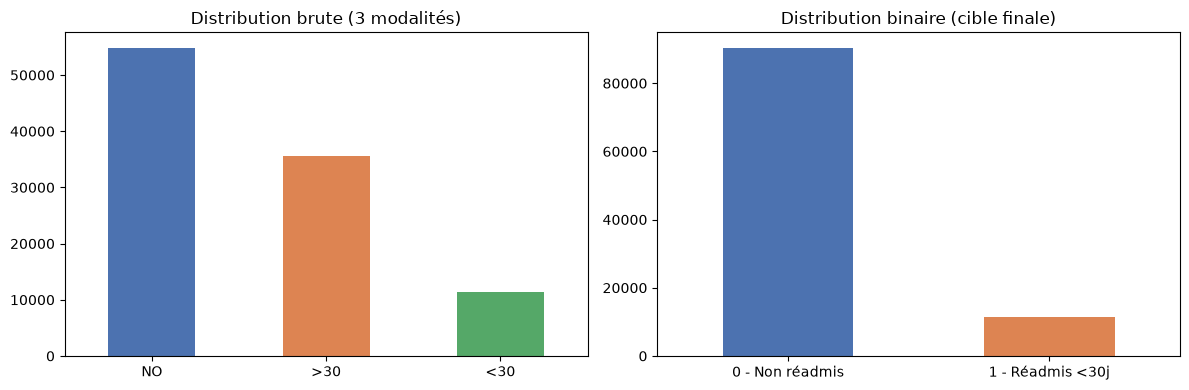

In [4]:
# Distribution brute des 3 modalités de readmitted
print("Distribution brute de readmitted :")
print(df['readmitted'].value_counts())
print(df['readmitted'].value_counts(normalize=True).round(3) * 100)

# Binarisation : <30 = 1 (classe positive), NO et >30 = 0 (classe négative)
df['readmitted_binary'] = (df['readmitted'] == '<30').astype(int)

# Taux de déséquilibre
taux = df['readmitted_binary'].value_counts(normalize=True) * 100
print(f"\nAprès binarisation :")
print(f"Classe 0 (non réadmis <30j) : {taux[0]:.1f}%")
print(f"Classe 1 (réadmis <30j)     : {taux[1]:.1f}%")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution brute
df['readmitted'].value_counts().plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452', '#55A868'])
axes[0].set_title('Distribution brute (3 modalités)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

# Distribution binaire
df['readmitted_binary'].value_counts().plot(kind='bar', ax=axes[1], color=['#4C72B0', '#DD8452'])
axes[1].set_title('Distribution binaire (cible finale)')
axes[1].set_xlabel('')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['0 - Non réadmis', '1 - Réadmis <30j'], rotation=0)

plt.tight_layout()
plt.savefig('data/raw/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
import os
print(os.getcwd())

C:\Python_Projects\hospital-readmit-mlops


## Section 5 — Analyse des doublons patient_nbr

In [5]:
# Nombre de patients uniques vs nombre de séjours
n_sejours = len(df)
n_patients = df['patient_nbr'].nunique()

print(f"Nombre de séjours     : {n_sejours}")
print(f"Nombre de patients    : {n_patients}")
print(f"Différence            : {n_sejours - n_patients}")

# Distribution du nombre de séjours par patient
sejours_par_patient = df.groupby('patient_nbr').size()
print(f"\nDistribution du nombre de séjours par patient :")
print(sejours_par_patient.value_counts().sort_index().head(10))

# Pourcentage de patients avec plusieurs séjours
multi_sejours = (sejours_par_patient > 1).sum()
print(f"\nPatients avec plusieurs séjours : {multi_sejours} ({multi_sejours/n_patients*100:.1f}%)")
print(f"Patients avec 1 seul séjour     : {(sejours_par_patient == 1).sum()} ({(sejours_par_patient == 1).sum()/n_patients*100:.1f}%)")

Nombre de séjours     : 101766
Nombre de patients    : 71518
Différence            : 30248

Distribution du nombre de séjours par patient :
1     54745
2     10434
3      3328
4      1421
5       717
6       346
7       207
8       111
9        70
10       42
Name: count, dtype: int64

Patients avec plusieurs séjours : 16773 (23.5%)
Patients avec 1 seul séjour     : 54745 (76.5%)


### ⚠️ Point méthodologique — Split train/test
23.5% des patients ont plusieurs séjours dans le dataset.
Le split train/test sera impérativement fait par `patient_nbr`
et non par séjour, pour éviter tout data leakage.

## Section 6 — Analyse des variables de diagnostic (diag_1, diag_2, diag_3)

In [6]:
# Nombre de modalités distinctes par variable de diagnostic
for col in ['diag_1', 'diag_2', 'diag_3']:
    print(f"{col} : {df[col].nunique()} modalités distinctes")

# Aperçu des premières valeurs pour comprendre la structure des codes ICD-9
print("\nExemples de valeurs diag_1 :")
print(df['diag_1'].value_counts().head(10))

diag_1 : 716 modalités distinctes
diag_2 : 748 modalités distinctes
diag_3 : 789 modalités distinctes

Exemples de valeurs diag_1 :
diag_1
428    6862
414    6581
786    4016
410    3614
486    3508
427    2766
491    2275
715    2151
682    2042
434    2028
Name: count, dtype: int64


Distribution des catégories diagnostiques (diag_1) :
diag_1_cat
Circulatory        30437
Other              18172
Respiratory        14423
Digestive           9475
Diabetes            8757
Injury              6974
Genitourinary       5117
Musculoskeletal     4957
Neoplasms           3433
Unknown               21
Name: count, dtype: int64


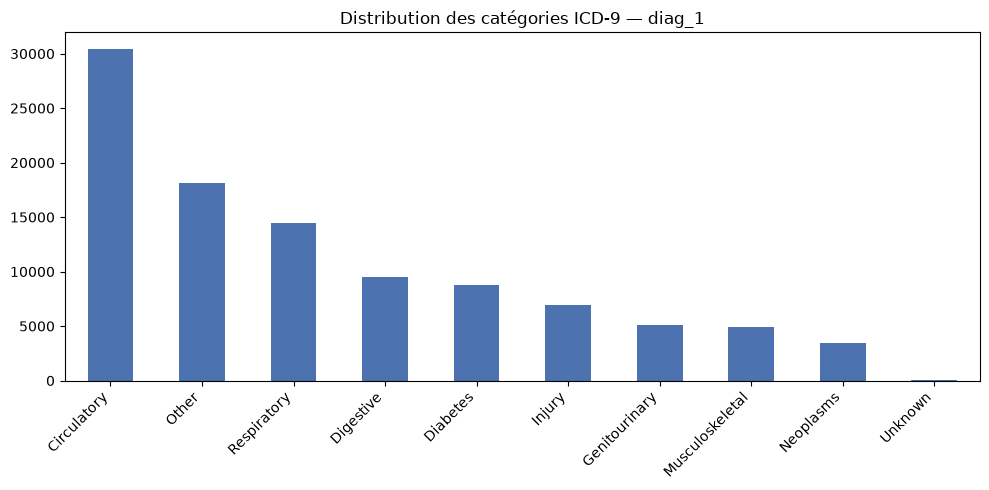

In [7]:
# Fonction de regroupement des codes ICD-9 en 9 catégories cliniques
# Basée sur le regroupement de Strack et al. (2014)
def group_icd9(code):
    if pd.isna(code):
        return 'Unknown'
    code = str(code)
    # Diabète
    if code.startswith('250'):
        return 'Diabetes'
    try:
        c = float(code)
        if 390 <= c <= 459 or c == 785: return 'Circulatory'
        if 460 <= c <= 519 or c == 786: return 'Respiratory'
        if 520 <= c <= 579 or c == 787: return 'Digestive'
        if 800 <= c <= 999:             return 'Injury'
        if 710 <= c <= 739:             return 'Musculoskeletal'
        if 580 <= c <= 629 or c == 788: return 'Genitourinary'
        if 140 <= c <= 239:             return 'Neoplasms'
    except:
        pass
    return 'Other'

# Application sur diag_1 uniquement pour l'EDA (diagnostic principal)
df['diag_1_cat'] = df['diag_1'].apply(group_icd9)

# Distribution des catégories
print("Distribution des catégories diagnostiques (diag_1) :")
print(df['diag_1_cat'].value_counts())

# Visualisation
plt.figure(figsize=(10, 5))
df['diag_1_cat'].value_counts().plot(kind='bar', color='#4C72B0')
plt.title('Distribution des catégories ICD-9 — diag_1')
plt.xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('data/raw/diag1_categories.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 7 — Distribution des variables numériques clés

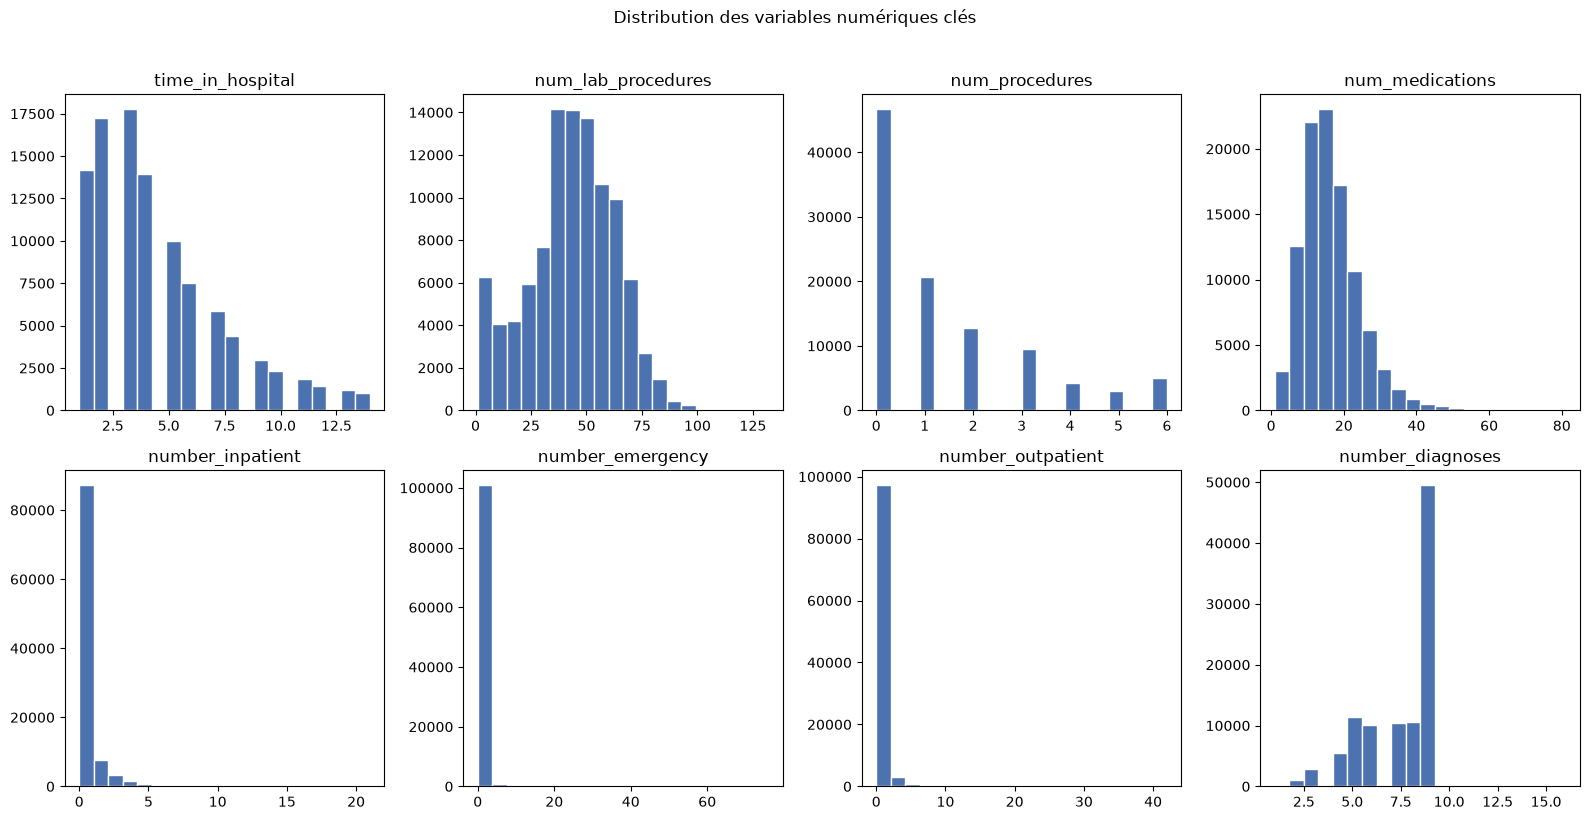

       time_in_hospital  num_lab_procedures  num_procedures  num_medications  \
count         101766.00           101766.00       101766.00        101766.00   
mean               4.40               43.10            1.34            16.02   
std                2.99               19.67            1.71             8.13   
min                1.00                1.00            0.00             1.00   
25%                2.00               31.00            0.00            10.00   
50%                4.00               44.00            1.00            15.00   
75%                6.00               57.00            2.00            20.00   
max               14.00              132.00            6.00            81.00   

       number_inpatient  number_emergency  number_outpatient  number_diagnoses  
count         101766.00         101766.00          101766.00         101766.00  
mean               0.64              0.20               0.37              7.42  
std                1.26             

In [8]:
# Variables numériques les plus pertinentes cliniquement
num_vars = ['time_in_hospital', 'num_lab_procedures', 
            'num_procedures', 'num_medications',
            'number_inpatient', 'number_emergency', 
            'number_outpatient', 'number_diagnoses']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_vars):
    axes[i].hist(df[col], bins=20, color='#4C72B0', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('')

plt.suptitle('Distribution des variables numériques clés', y=1.02)
plt.tight_layout()
plt.savefig('data/raw/numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistiques descriptives synthétiques
print(df[num_vars].describe().round(2))

## Section 8 — Relation entre variables prédictives et la cible

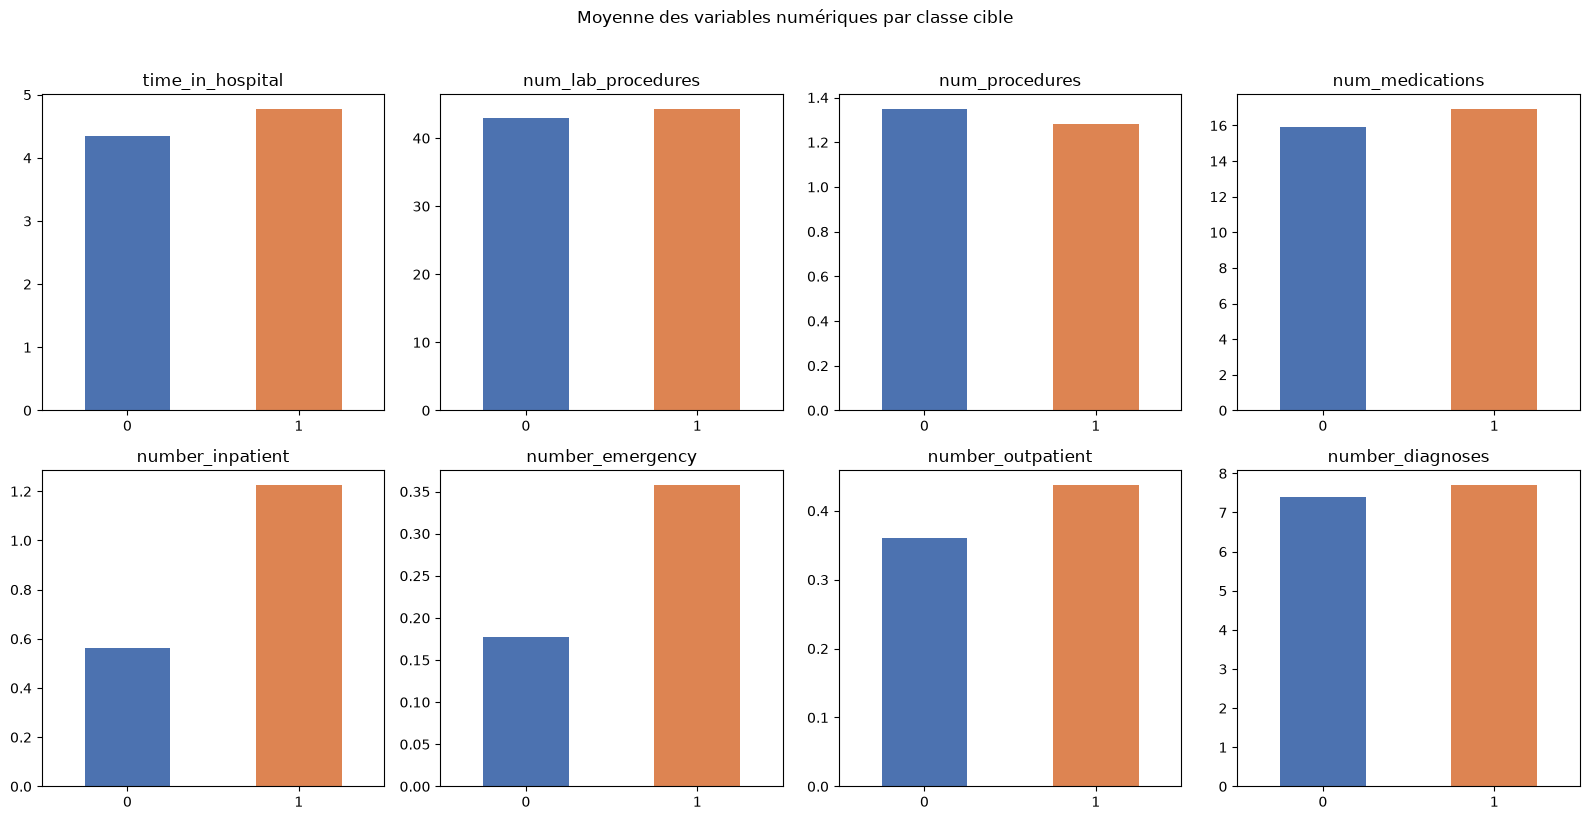

In [9]:
# Taux de réadmission <30j par variable numérique clé
# On compare les distributions entre classe 0 et classe 1
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_vars):
    df.groupby('readmitted_binary')[col].mean().plot(
        kind='bar', ax=axes[i], color=['#4C72B0', '#DD8452']
    )
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=0)

plt.suptitle('Moyenne des variables numériques par classe cible', y=1.02)
plt.tight_layout()
plt.savefig('data/raw/numeric_vs_target.png', dpi=150, bbox_inches='tight')
plt.show()

### Taux de réadmission par variables catégorielles clés

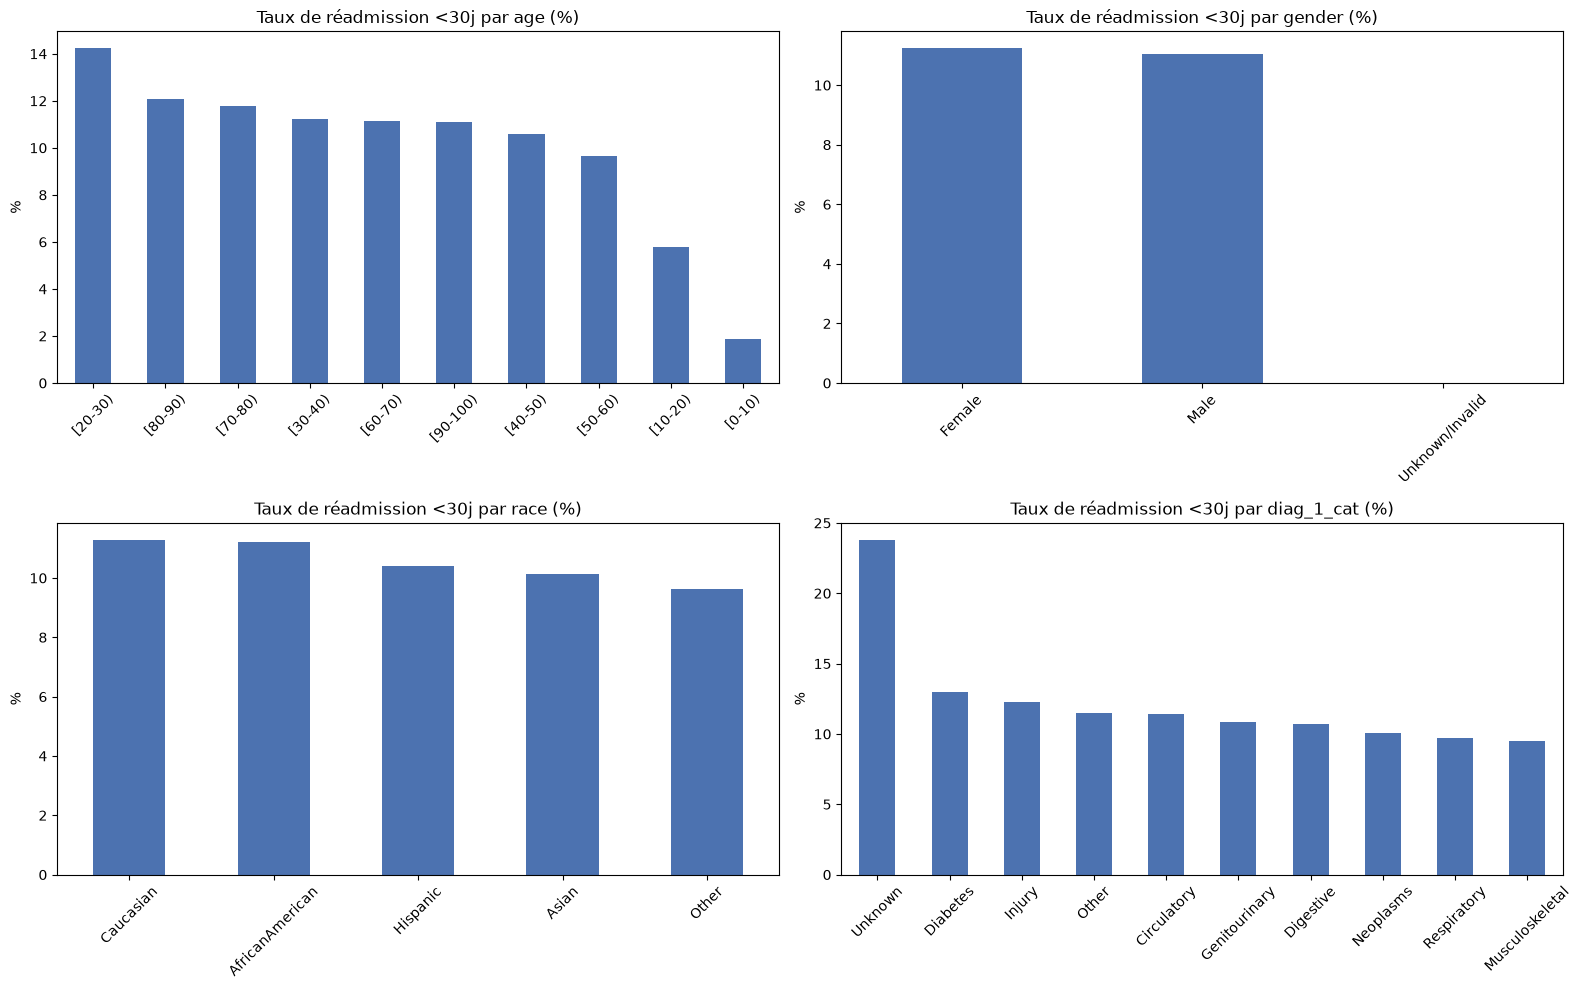

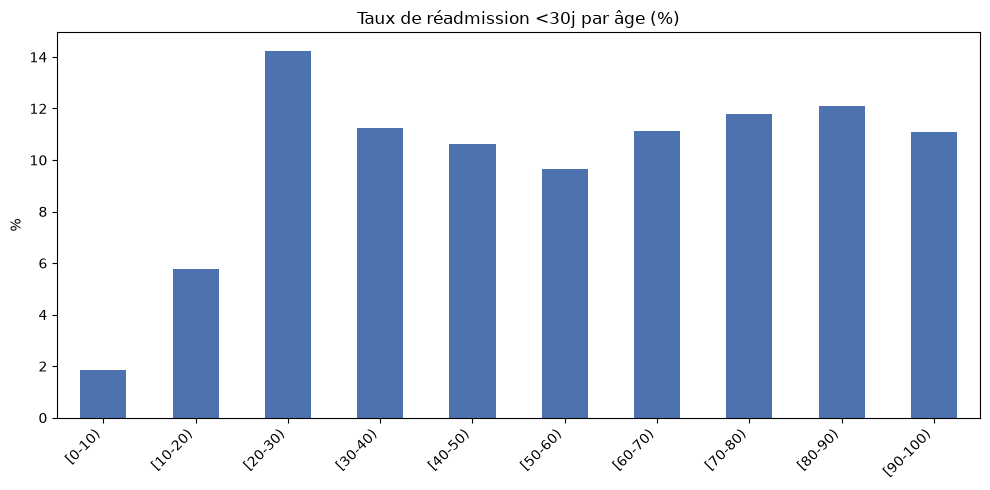

In [10]:
# Taux de réadmission <30j par variable catégorielle
cat_vars = ['age', 'gender', 'race', 'diag_1_cat']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_vars):
    taux_readmission = df.groupby(col)['readmitted_binary'].mean() * 100
    taux_readmission.sort_values(ascending=False).plot(
        kind='bar', ax=axes[i], color='#4C72B0'
    )
    axes[i].set_title(f'Taux de réadmission <30j par {col} (%)')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel('%')

plt.tight_layout()
plt.savefig('data/raw/categorical_vs_target.png', dpi=150, bbox_inches='tight')
plt.show()

# Ordre chronologique des tranches d'âge
age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)', 
             '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']

taux_age = df.groupby('age')['readmitted_binary'].mean() * 100
taux_age = taux_age.reindex(age_order)

plt.figure(figsize=(10, 5))
taux_age.plot(kind='bar', color='#4C72B0')
plt.title('Taux de réadmission <30j par âge (%)')
plt.xlabel('')
plt.ylabel('%')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('data/raw/age_vs_target.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 9 — Synthèse EDA

### Points clés retenus pour la modélisation

**Données :**
- 101 766 séjours, 71 518 patients uniques → split train/test impérativement par `patient_nbr`
- Valeurs manquantes encodées "?" → remplacées par NaN
- `weight`, `max_glu_serum`, `A1Cresult` à supprimer (>83% de manquants)
- `medical_specialty`, `payer_code` → catégorie "Unknown"
- `diag_1/2/3` → regroupement en 9 catégories ICD-9 (Strack et al.)

**Cible :**
- Déséquilibre marqué : 11% de réadmissions <30j → nécessite une stratégie de rééquilibrage (J3)

**Variables les plus discriminantes :**
- `number_inpatient` et `number_emergency` : différences les plus marquées entre classes
- `diag_1_cat` : Diabetes comme diagnostic principal associé à un taux plus élevé
- `age` : pas de gradient monotone — taux instables chez les jeunes (<30 ans, effectifs faibles),
   taux stables ~10-12% à partir de 50 ans

**Variables probablement peu prédictives seules :**
- `gender`, `race`
- `time_in_hospital`, `num_lab_procedures`, `num_procedures`